In [15]:
from datasets import load_dataset

dataset = load_dataset("ag_news")  

In [16]:
train_data = dataset["train"]
test_data = dataset["test"]

In [17]:
X = []
y = []

for i in range(len(train_data)):
    text = train_data[i]["Title"] + " " + train_data[i]["Description"]
    label = train_data[i]["Class Index"]

    X.append(text)
    y.append(label)

In [18]:
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)

    words = text.split()
    words = [w for w in words if w not in stop_words]

    return " ".join(words)

In [19]:
X = [preprocess(text) for text in X]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2))

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=300)
model.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
y_pred = model.predict(X_test_vec)

In [24]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9165416666666667
              precision    recall  f1-score   support

           1       0.93      0.90      0.91      5956
           2       0.95      0.98      0.97      6058
           3       0.88      0.89      0.89      5911
           4       0.90      0.89      0.90      6075

    accuracy                           0.92     24000
   macro avg       0.92      0.92      0.92     24000
weighted avg       0.92      0.92      0.92     24000



In [25]:
label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

def predict_news(text):
    text = preprocess(text)
    vec = vectorizer.transform([text])
    label = model.predict(vec)[0]
    return label_map[label]

In [26]:
print(predict_news("The football team won the championship match"))
print(predict_news("The government passed a new law today"))
print(predict_news("Apple releases new AI powered chip"))
print(predict_news("Stock markets rise after economic recovery"))

Sports
World
Sci/Tech
Business


In [27]:
import ipywidgets as widgets
from IPython.display import display

In [ ]:
text_box = widgets.Textarea(
    placeholder="Enter news article here...",
    layout=widgets.Layout(width="80%", height="120px")
)

button = widgets.Button(description="Predict", button_style="success")
output = widgets.Output()

display(text_box, button, output)

Textarea(value='', layout=Layout(height='120px', width='80%'), placeholder='Enter news article here...')

Button(button_style='success', description='Predict', style=ButtonStyle())

Output()

In [29]:
def on_click(b):
    with output:
        output.clear_output()

        text = text_box.value

        if text.strip() == "":
            print("⚠️ Please enter text")
            return

        result = predict_news(text)
        print("📰 Predicted Category:", result)

button.on_click(on_click)

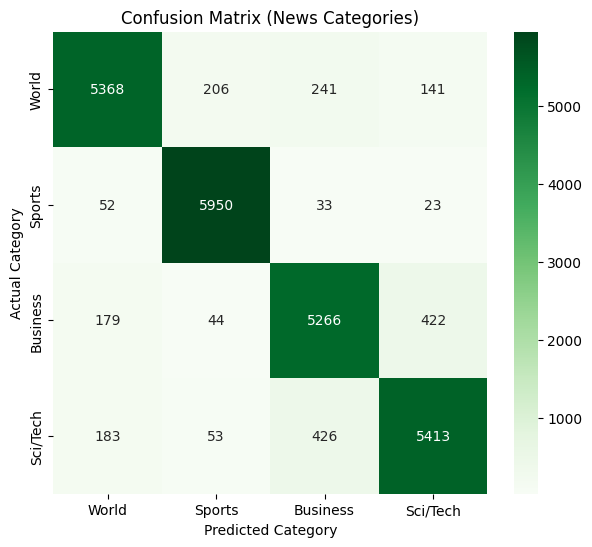

In [36]:
labels = ["World", "Sports", "Business", "Sci/Tech"]
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels,
            yticklabels=labels)

plt.title("Confusion Matrix (News Categories)")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.show()

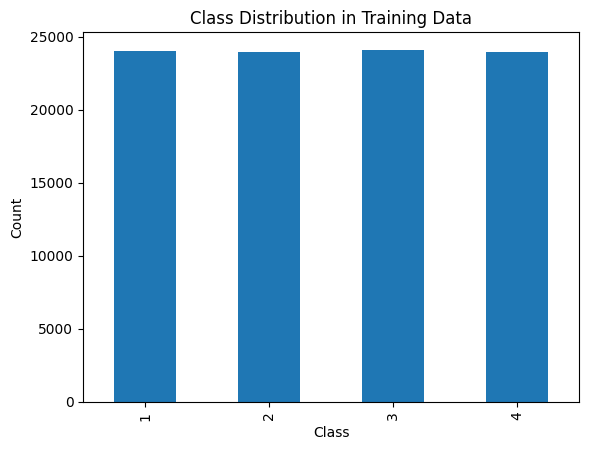

In [37]:
import pandas as pd

plt.figure()
pd.Series(y_train).value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution in Training Data")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()